# Predicting House Prices

##Problem Definition

The goal of this project is to build a Linear Regression model that predicts SalePrice using housing data from the Amazon Housing dataset. This baseline model uses Gr Liv Area as the predictor variable, and model performance will be evaluated using Root Mean Squared Percentage Error (RMSPE) .


##Data Collection

In [1]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn import datasets
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

In [2]:
url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv'
url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv'

In [3]:
df = pd.read_csv(url)
df

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,903231070,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,400,9,2006,WD,Normal,114500
2633,906201021,80,RL,74.0,10778,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,162000
2634,533253070,120,RL,61.0,3782,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,211500
2635,527376100,20,RL,78.0,10140,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2009,WD,Normal,165000


In [4]:
#Rows and Columns
df.shape

(2637, 81)

###Columns

####Find Identifier Columns

In [5]:
#Run code to identifier columns
identifier_cols = []

for col in df.columns:
    if df[col].nunique() == len(df):
        identifier_cols.append(col)

print(identifier_cols)

['PID']


In [6]:
#Verify all rows are unique
df['PID'].nunique()

2637

In [7]:
#Must match df['target'].nunique
len(df)

2637

####Verify Target Column doesn't have any nulls

In [8]:
#Rows with nulls in target column
df['PID'].isnull().sum()

np.int64(0)

####Feature columns

In [9]:
#Drop target column
df.drop(columns=['PID'], inplace=True)

In [10]:
#View all columns in a sorted list
# df.columns.sort_values().to_list()

In [11]:
#Rows with nulls in each
df.isnull().sum().sort_values()*1000

,0
MS SubClass,0
MS Zoning,0
Lot Area,0
Street,0
Land Contour,0
...,...
Mas Vnr Type,1607000
Fence,2109000
Alley,2457000
Misc Feature,2541000


####Numerical/Categorical columns

In [12]:
#Look for int, float, object totals at the bottom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2637 non-null   int64  
 1   MS Zoning        2637 non-null   object 
 2   Lot Frontage     2188 non-null   float64
 3   Lot Area         2637 non-null   int64  
 4   Street           2637 non-null   object 
 5   Alley            180 non-null    object 
 6   Lot Shape        2637 non-null   object 
 7   Land Contour     2637 non-null   object 
 8   Utilities        2637 non-null   object 
 9   Lot Config       2637 non-null   object 
 10  Land Slope       2637 non-null   object 
 11  Neighborhood     2637 non-null   object 
 12  Condition 1      2637 non-null   object 
 13  Condition 2      2637 non-null   object 
 14  Bldg Type        2637 non-null   object 
 15  House Style      2637 non-null   object 
 16  Overall Qual     2637 non-null   int64  
 17  Overall Cond  

###Rows

In [13]:
df.isnull().sum().sort_values()

,0
MS SubClass,0
MS Zoning,0
Lot Area,0
Street,0
Land Contour,0
...,...
Mas Vnr Type,1607
Fence,2109
Alley,2457
Misc Feature,2541


In [14]:
#Duplicate rows
df.duplicated().sum()

np.int64(0)

In [15]:
#Missing rows
df.isnull().sum().sort_values()

,0
MS SubClass,0
MS Zoning,0
Lot Area,0
Street,0
Land Contour,0
...,...
Mas Vnr Type,1607
Fence,2109
Alley,2457
Misc Feature,2541


##Data Cleaning

In [16]:
df['SalePrice'].isna().sum()

np.int64(0)

In [17]:
df['SalePrice'].describe()

,SalePrice
count,2637.000000
mean,179986.230186
std,78309.251522
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213000.000000
max,745000.000000


In [18]:
df.dtypes.value_counts()

,count
object,43
int64,26
float64,11


Int Fields

In [19]:
df_int = df.select_dtypes(include=['int64']).drop(columns=['SalePrice'])
df_int

,MS SubClass,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,...,Fireplaces,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold
0,20,14299,4,3,1964,1964,1005,0,0,1005,...,0,0,0,0,0,0,0,0,7,2007
1,90,10791,4,5,1967,1967,1296,0,0,1296,...,0,0,0,0,0,0,0,500,10,2006
2,50,9000,6,6,1937,1950,780,595,0,1375,...,1,0,162,0,0,126,0,0,12,2007
3,60,7379,8,5,2000,2000,975,873,0,1848,...,1,280,184,0,0,0,0,0,4,2010
4,70,7200,7,9,1936,2007,575,560,0,1135,...,0,256,0,0,0,0,0,0,4,2009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,50,6240,6,6,1934,1950,816,0,360,1176,...,1,112,0,0,0,0,0,400,9,2006
2633,80,10778,7,6,1990,1991,1061,0,0,1061,...,0,114,36,0,0,0,0,0,7,2009
2634,120,3782,8,5,1981,1981,1226,0,0,1226,...,2,133,78,0,0,0,0,0,9,2009
2635,20,10140,6,5,1974,1974,1350,0,0,1350,...,1,0,0,0,0,0,0,0,8,2009


In [20]:
df.select_dtypes(include=['int64']).isna().sum()*1000

,0
MS SubClass,0
Lot Area,0
Overall Qual,0
Overall Cond,0
Year Built,0
Year Remod/Add,0
1st Flr SF,0
2nd Flr SF,0
Low Qual Fin SF,0
Gr Liv Area,0


In [21]:
df['Gr Liv Area'].isna().sum()

np.int64(0)

##Exploratory Data Analysis (EDA)

In [22]:
cols = ['SalePrice'] + df_int.columns.tolist()
df_lr = df[cols]
df_lr

,SalePrice,MS SubClass,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,1st Flr SF,2nd Flr SF,Low Qual Fin SF,...,Fireplaces,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold
0,115400,20,14299,4,3,1964,1964,1005,0,0,...,0,0,0,0,0,0,0,0,7,2007
1,90000,90,10791,4,5,1967,1967,1296,0,0,...,0,0,0,0,0,0,0,500,10,2006
2,141000,50,9000,6,6,1937,1950,780,595,0,...,1,0,162,0,0,126,0,0,12,2007
3,254000,60,7379,8,5,2000,2000,975,873,0,...,1,280,184,0,0,0,0,0,4,2010
4,155000,70,7200,7,9,1936,2007,575,560,0,...,0,256,0,0,0,0,0,0,4,2009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,114500,50,6240,6,6,1934,1950,816,0,360,...,1,112,0,0,0,0,0,400,9,2006
2633,162000,80,10778,7,6,1990,1991,1061,0,0,...,0,114,36,0,0,0,0,0,7,2009
2634,211500,120,3782,8,5,1981,1981,1226,0,0,...,2,133,78,0,0,0,0,0,9,2009
2635,165000,20,10140,6,5,1974,1974,1350,0,0,...,1,0,0,0,0,0,0,0,8,2009


###Histogram

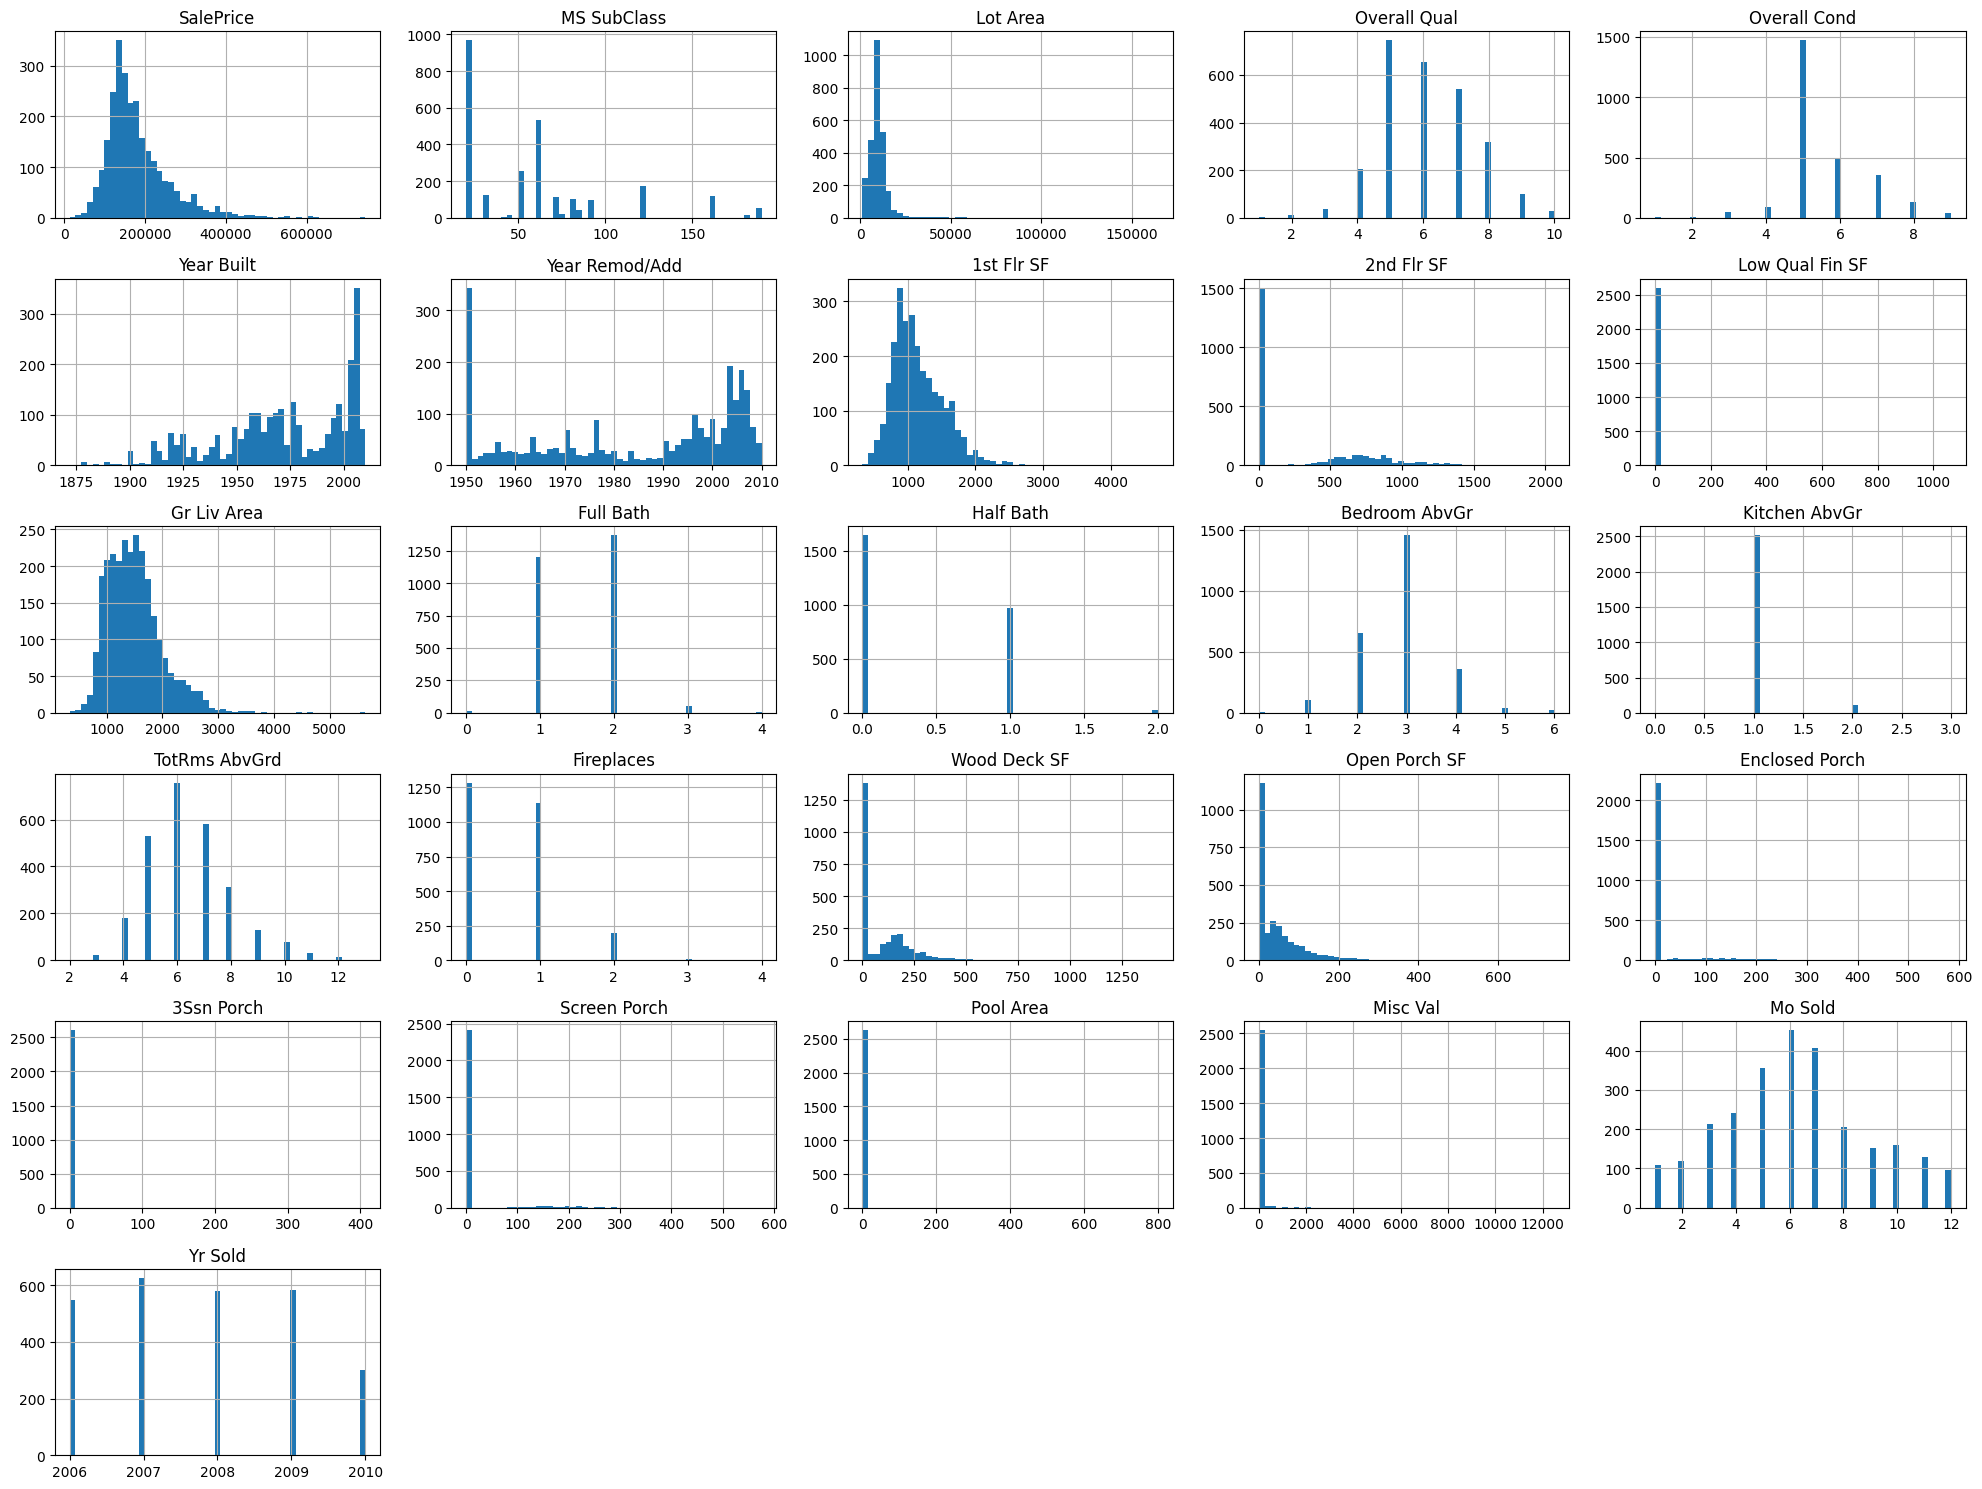

In [23]:
n = int(2637**(1/2))

#SalePrice

df_lr.hist(figsize=(20, 15), bins=n)

plt.tight_layout()
plt.show()

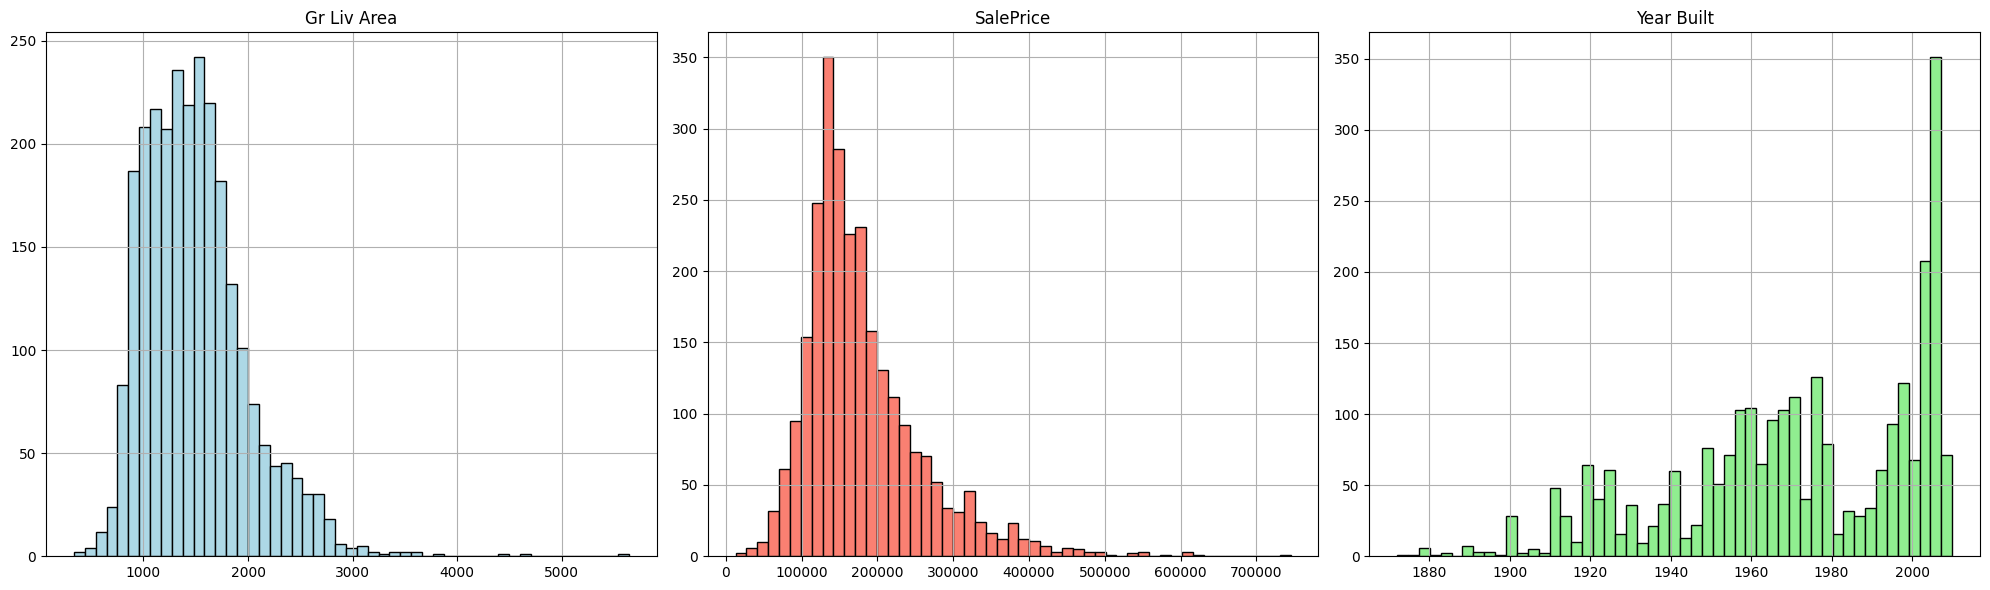

In [24]:
# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot each column into its corresponding axis (ax=axes[0], ax=axes[1], etc.)
df_lr['Gr Liv Area'].hist(ax=axes[0], bins=n, color='lightblue', edgecolor='black')
axes[0].set_title('Gr Liv Area')

df_lr['SalePrice'].hist(ax=axes[1], bins=n, color='salmon', edgecolor='black')
axes[1].set_title('SalePrice')

df_lr['Year Built'].hist(ax=axes[2], bins=n, color='lightgreen', edgecolor='black')
axes[2].set_title('Year Built')

plt.tight_layout()
plt.savefig("Housing_Histogram_Row.png")
plt.show()

###Boxplot

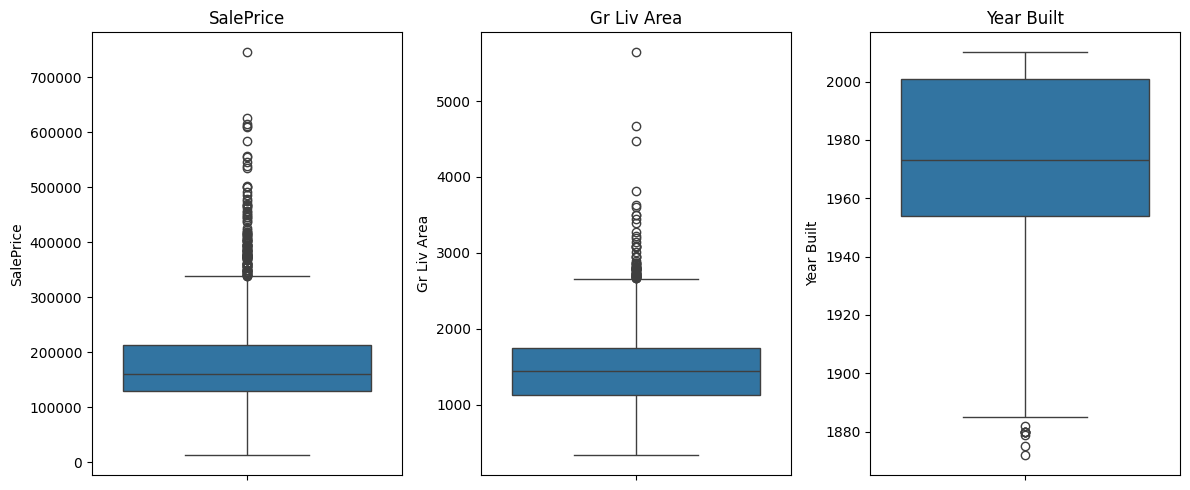

In [25]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5))

#SalePrice
sns.boxplot(y=df_lr["SalePrice"], ax=ax[0])
ax[0].set_title("SalePrice")

#LotArea
sns.boxplot(y=df_lr["Gr Liv Area"], ax=ax[1])
ax[1].set_title("Gr Liv Area")

#LotArea
sns.boxplot(y=df_lr["Year Built"], ax=ax[2])
ax[2].set_title("Year Built")

plt.tight_layout()
plt.show()

###Correlation

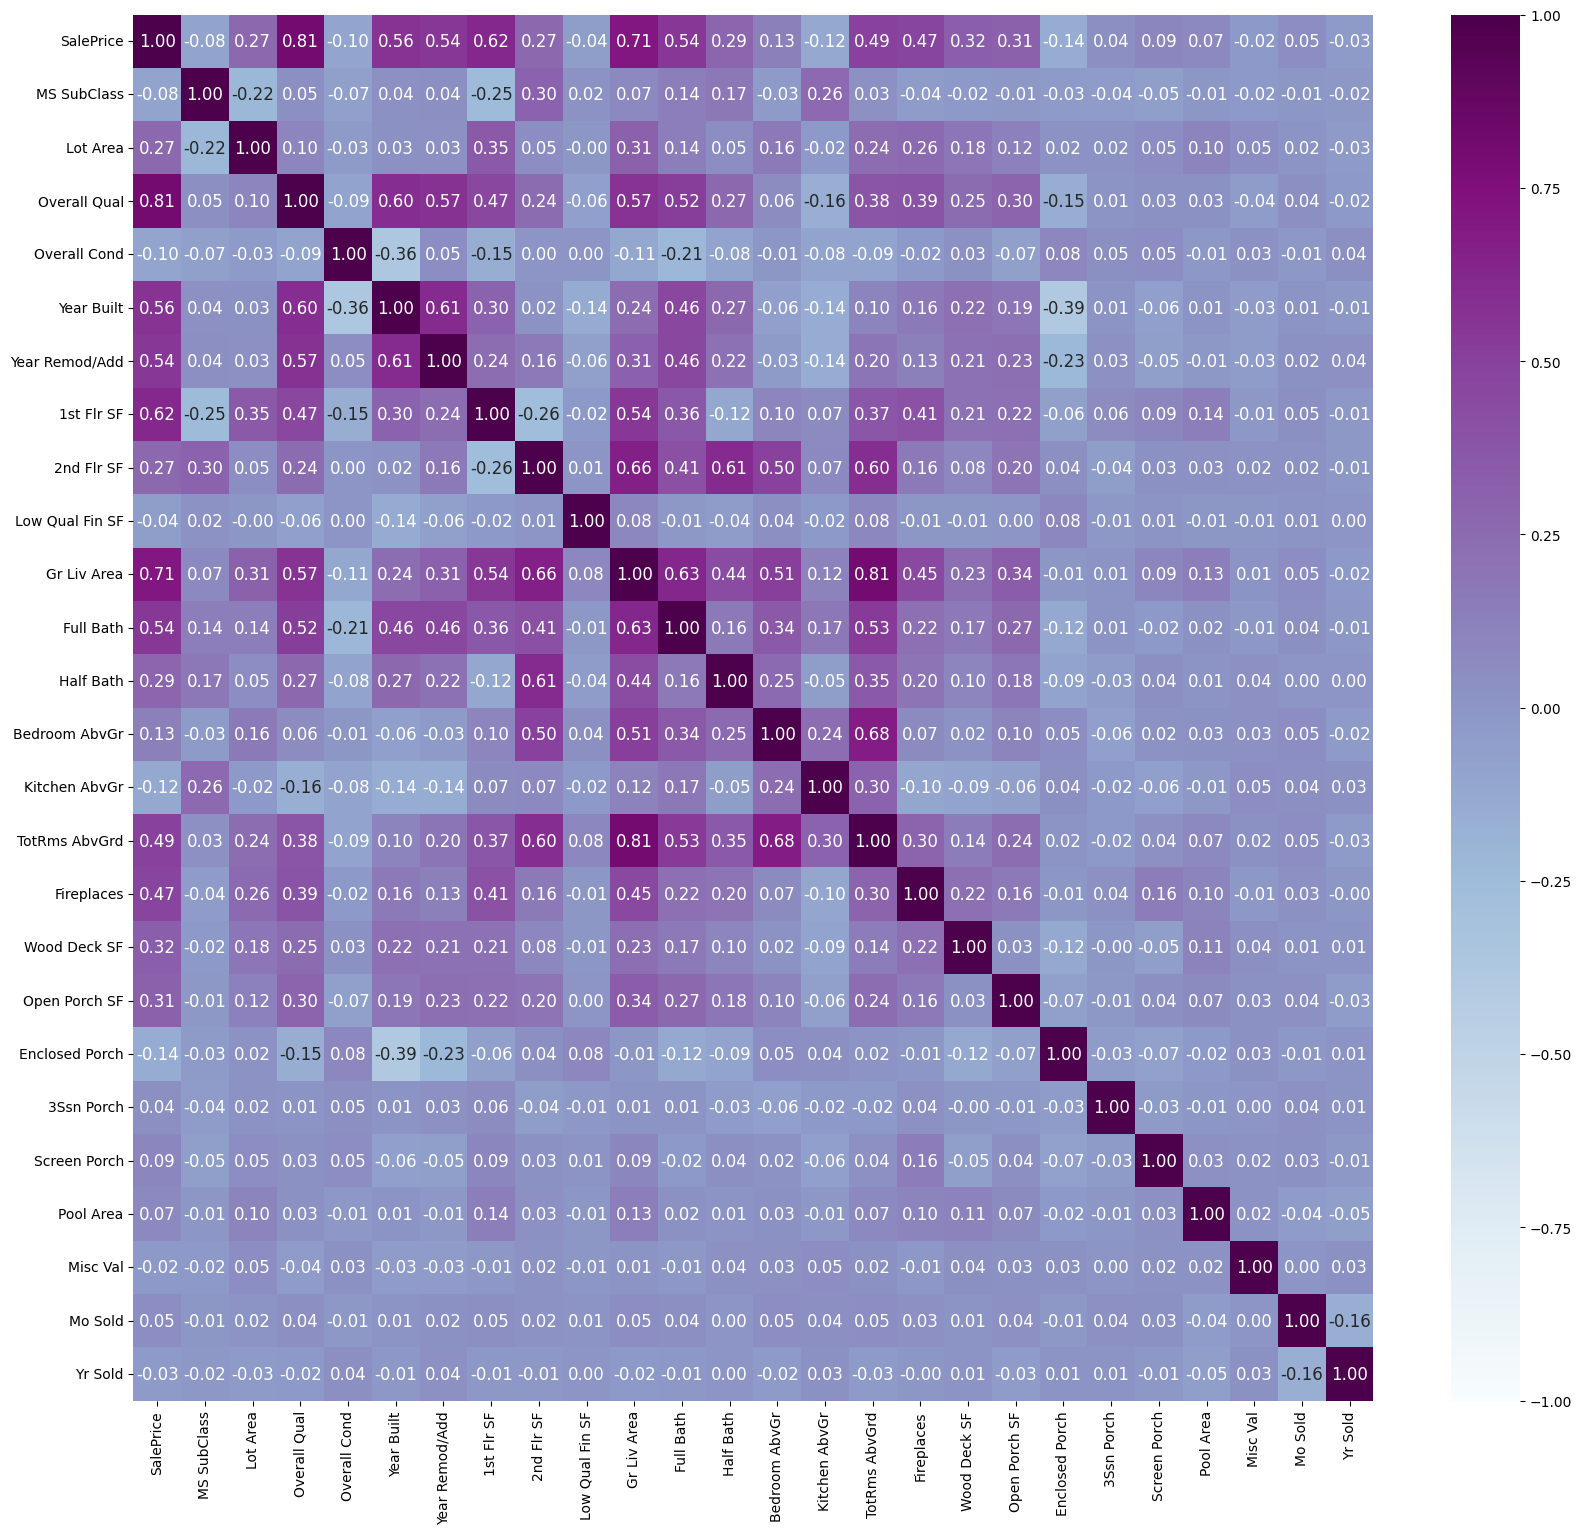

In [26]:
corr = df_lr.corr()

plt.figure(figsize=(20, 18))

sns.heatmap(
    corr,
    annot=True,
    cmap='BuPu',
    vmin=-1,
    vmax=1,
    annot_kws={"size": 12},
    fmt=".2f"
)

plt.show()

##Linear Regresssion Model

In [27]:
#First we will break up our data into training and testing sets
X = df_lr[['Gr Liv Area', 'Year Built']].copy()
y = df_lr['SalePrice']

#Normalize the features
scaler = StandardScaler()
scaler.fit_transform(X)

array([[-0.9936772 , -0.24053754],
       [-0.40593582, -0.14153169],
       [-0.24637717, -1.1315902 ],
       ...,
       [-0.54731691,  0.32049562],
       [-0.29687041,  0.08948197],
       [ 1.66630698,  0.91453073]])

In [28]:
X.columns

Index(['Gr Liv Area', 'Year Built'], dtype='object')

In [29]:
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state=5)

In [30]:
X.head()

,Gr Liv Area,Year Built
0,1005,1964
1,1296,1967
2,1375,1937
3,1848,2000
4,1135,1936


In [31]:
X_scaled.head()

,Gr Liv Area,Year Built
0,-0.993677,-0.240538
1,-0.405936,-0.141532
2,-0.246377,-1.131590
3,0.708955,0.947533
4,-0.731112,-1.164592


In [32]:
#Fit a linear model using Sklearn
model = LinearRegression()
my_fit_lr = model.fit(X_train, y_train)

In [33]:
#Create a data frame with the results from the linear regression models
model_results = pd.DataFrame()
model_results['Predictor'] = X_train.columns
model_results['Linear'] = my_fit_lr.coef_
model_results.sort_values(by=['Linear'],inplace=True, ascending=False)
model_results

,Predictor,Linear
0,Gr Liv Area,47651.673430
1,Year Built,32731.095289


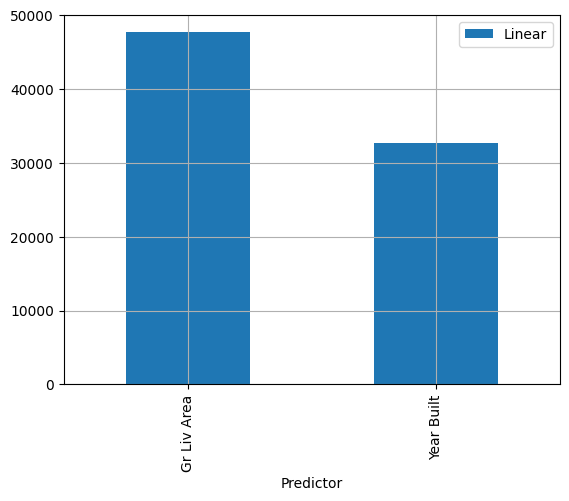

In [34]:
#We can even plot the coefficients if we want to!
model_results.plot(x = 'Predictor', y = 'Linear', kind = 'bar')
plt.grid()

In [35]:
#Calculate CV RMSE
results = cross_val_score(
    model,
    X_scaled,
    y,
    scoring='neg_root_mean_squared_error',
    cv = 10
    )
rmse = abs(results.mean())
print(f"CV RMSE: {rmse}")

CV RMSE: 45273.89300848707


###Residual Analysis

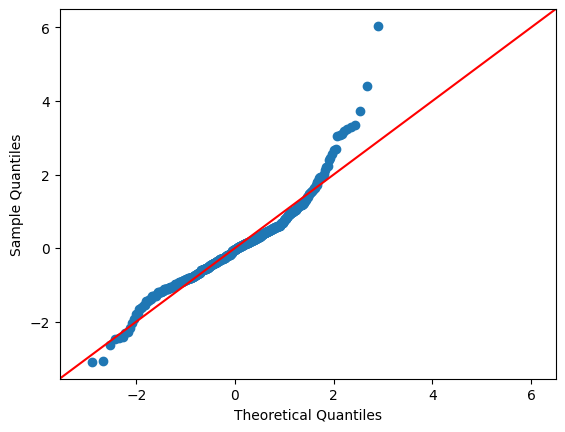

In [36]:
#QQ Plot - Residuals are normally distributed
# 1. Get predictions on the test set
y_pred = my_fit_lr.predict(X_test)

res = y_test - y_pred
sm.qqplot(res, fit=True, line="45")

plt.savefig('Linear_Residuals.png')

## Regularization - Ridge Regression

In [37]:
#Train the model
my_fit_rr = Ridge(alpha = 1) # Arbitrarily choosing alpha = 1
my_fit_rr.fit(X_train, y_train);

In [38]:
#Calculate RMSE
y_pred = my_fit_rr.predict(X_test)
rmse = np.sqrt(np.mean(np.square(y_test - y_pred)))
print(f"RMSE: {rmse}")

RMSE: 41001.761562177504


In [39]:
#Specify values of alpha we want to try
alpha = [1e-15, 1e-10, 1e-8, 1e-4, 1e-3, 1e-2, 1e-1, 1, 2, 3, 4, 5, 10, 20, 30, 50]

#Create empty list to hold results
results_alpha = []

for a in alpha:
  #Train the model
  my_fit_rr = Ridge(alpha = a) #Looping through alpha
  my_fit_rr.fit(X_train, y_train)

  #Calculate CV RMSE
  results = cross_val_score(
      my_fit_rr,
      X_scaled,
      y,
      scoring='neg_root_mean_squared_error',
      cv = 10
      )
  rmse = abs(results.mean())
  results_alpha.append(rmse)

results_df = pd.DataFrame({'Alpha': alpha, 'RMSE': results_alpha})
print(results_df.sort_values(by=['RMSE']))

           Alpha          RMSE
0   1.000000e-15  45273.893008
1   1.000000e-10  45273.893008
2   1.000000e-08  45273.893008
3   1.000000e-04  45273.893009
4   1.000000e-03  45273.893016
5   1.000000e-02  45273.893081
6   1.000000e-01  45273.893786
7   1.000000e+00  45273.905615
8   2.000000e+00  45273.928943
9   3.000000e+00  45273.962970
10  4.000000e+00  45274.007675
11  5.000000e+00  45274.063034
12  1.000000e+01  45274.498858
13  2.000000e+01  45276.156740
14  3.000000e+01  45278.844581
15  5.000000e+01  45287.223830


In [40]:
results_df.sort_values( by = ["Alpha"])

,Alpha,RMSE
0,1.000000e-15,45273.893008
1,1.000000e-10,45273.893008
2,1.000000e-08,45273.893008
3,1.000000e-04,45273.893009
4,1.000000e-03,45273.893016
5,1.000000e-02,45273.893081
6,1.000000e-01,45273.893786
7,1.000000e+00,45273.905615
8,2.000000e+00,45273.928943
9,3.000000e+00,45273.962970


In [41]:
#Retrain the model w/ alpha = 20
my_fit_rr = Ridge(alpha = 30)
my_fit_rr.fit(X_train, y_train)

#Calculate CV RMSE
results = cross_val_score(my_fit_rr, X_scaled, y, scoring='neg_root_mean_squared_error', cv = 10)
rmse = abs(results.mean())
print(f"CV RMSE: {rmse}")

CV RMSE: 45278.84458092808


In [42]:
#Add ridge regression results to data frame we created earlier
model_results['Ridge'] = my_fit_rr.coef_

In [43]:
model_results

,Predictor,Linear,Ridge
0,Gr Liv Area,47651.673430,47071.691728
1,Year Built,32731.095289,32404.889669


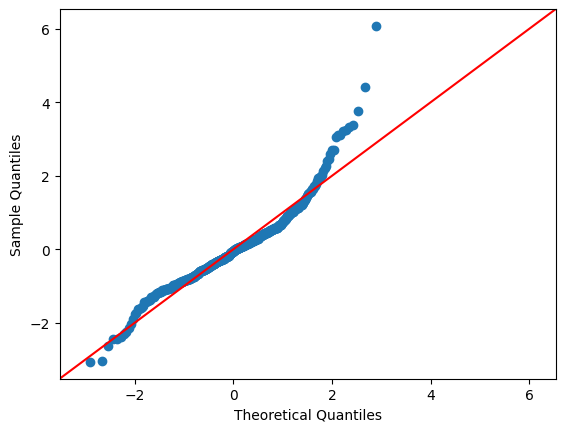

In [44]:
#QQ Plot - Residuals are normally distributed
# 1. Get predictions on the test set
y_pred = my_fit_rr.predict(X_test)

res = y_test - y_pred
sm.qqplot(res, fit=True, line="45")

plt.savefig('Ridge_Residuals.png')

## Regularization - Lasso Regression


In [45]:
#Specify values of alpha we want to try
alpha = [1e-15, 1e-10, 1e-8, 1e-4, 1e-3, 1e-2, 1e-1, 1, 2, 3, 4, 5, 10, 20, 30, 50]

#Create empty list to hold results
results_alpha = []

for i in alpha:
  #Train the model
  my_fit_lasso = Lasso(alpha = i, tol = .01, max_iter=100_000) # Looping through alpha
  my_fit_lasso.fit(X_train, y_train)

  #Calculate CV RMSE
  results = cross_val_score(
      my_fit_lasso,
      X_scaled,
      y,
      scoring='neg_root_mean_squared_error',
      cv = 10
  )
  rmse = abs(results.mean())
  results_alpha.append(rmse)

results_df = pd.DataFrame({'Alpha': alpha, 'RMSE': results_alpha})
print(results_df.sort_values(by=['RMSE']))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.277e+12, tolerance: 1.325e+11
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.504e+12, tolerance: 1.461e+11
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.432e+12, tolerance: 1.438e

           Alpha          RMSE
12  1.000000e+01  45273.301636
13  2.000000e+01  45273.891450
3   1.000000e-04  45273.893004
1   1.000000e-10  45273.893008
0   1.000000e-15  45273.893008
2   1.000000e-08  45273.893008
4   1.000000e-03  45273.893012
5   1.000000e-02  45273.893052
6   1.000000e-01  45273.893503
7   1.000000e+00  45273.897477
8   2.000000e+00  45273.898632
9   3.000000e+00  45273.899823
10  4.000000e+00  45273.901050
11  5.000000e+00  45273.902313
14  3.000000e+01  45273.907981
15  5.000000e+01  45273.951790


In [46]:
results_df

,Alpha,RMSE
0,1.000000e-15,45273.893008
1,1.000000e-10,45273.893008
2,1.000000e-08,45273.893008
3,1.000000e-04,45273.893004
4,1.000000e-03,45273.893012
5,1.000000e-02,45273.893052
6,1.000000e-01,45273.893503
7,1.000000e+00,45273.897477
8,2.000000e+00,45273.898632
9,3.000000e+00,45273.899823


In [47]:
#Train the model
my_fit_lasso = Lasso(alpha = 20, tol = .01, max_iter=1_000_000)
my_fit_lasso.fit(X_train, y_train)

#Calculate CV RMSE
results = cross_val_score(my_fit_lasso, X_scaled, y, scoring='neg_root_mean_squared_error', cv = 10)
rmse = abs(results.mean())
print(f"CV RMSE: {rmse}")

CV RMSE: 45273.89144977506


In [48]:
#Add Lasso results to the data frame we created before
model_results['Lasso'] = my_fit_lasso.coef_

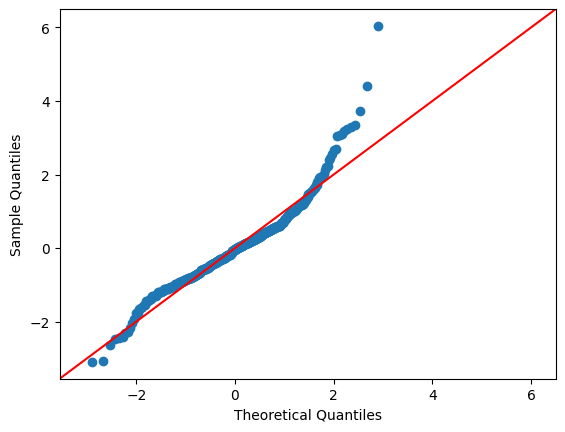

In [49]:
#QQ Plot - Residuals are normally distributed
# 1. Get predictions on the test set
y_pred = my_fit_lasso.predict(X_test)

res = y_test - y_pred
sm.qqplot(res, fit=True, line="45")

plt.savefig('Linear_Residuals.png')

## Summary

In [50]:
model_results

,Predictor,Linear,Ridge,Lasso
0,Gr Liv Area,47651.673430,47071.691728,47652.837055
1,Year Built,32731.095289,32404.889669,32711.082789


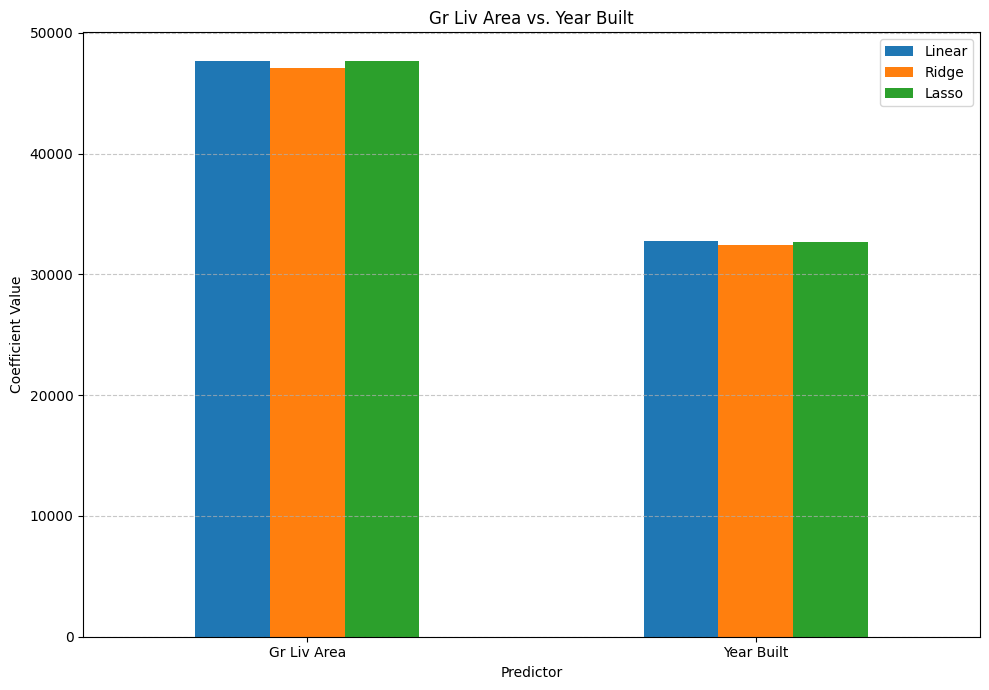

In [52]:
#Plot results
fig, ax = plt.subplots(1,1, figsize = (10,7))
model_results.plot(x = 'Predictor', kind = 'bar', ax = ax, rot=0)

ax.set_ylabel('Coefficient Value')
ax.set_title('Gr Liv Area vs. Year Built')
ax.set_title('Gr Liv Area vs. Year Built')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot
plt.savefig("model_coefficients.png")
plt.show()

##Data Visualization/Communication of Results